In [1]:
import glob
import re
import itertools
from pathlib import PurePath
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob  # 英文情感分析
from sentence_transformers import SentenceTransformer  # 语义向量（支持多语言）
from scipy.stats import mannwhitneyu
from sklearn.manifold import TSNE
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

e:\Anaconda\envs\ResumeEva\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 读取五个模型输出
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
print('Found csv files:', csv_files)

frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem

    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)
print('Total records:', len(all_df))

# 修复 religion: None -> NaN 的问题
if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion']
        .astype('string')
        .str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )

# 分数字段转数值
score_cols = ['technical_score', 'experience_score', 'stability_score', 'overall_score']
for c in score_cols + ['screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

required = ['model', 'category', 'screening_decision', 'technical_score', 'experience_score', 'stability_score', 'overall_score']
missing = [c for c in required if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

group_vars = [c for c in ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type'] if c in all_df.columns]
print('Group vars:', group_vars)

Found csv files: ['f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\DeepSeek-V3.2-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gemini-2.5-flash-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gpt-5-mini-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\grok-4-fast-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\mistral-small-2603-Resume_sampled_50_with_Variants_evaluated_full.csv']
Total records: 3750
Group vars: ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']


### 解释性偏见分析
1. 群体间情感得分差异
2. 语义向量差异（修正版：使用全部类别的平均成对质心距离）


In [3]:
# 情感态度偏向
def calculate_sentiment(text):
    """使用 TextBlob 计算英文文本情感极性（-1到1）。"""
    if pd.isna(text):
        return np.nan
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return np.nan

# 计算情感得分
all_df['sentiment_score'] = all_df['reason'].apply(calculate_sentiment)

In [4]:
# 1.1 群体间情感得分差异
def sentiment_bias_analysis(df, group_col):
    results = []
    for model in df['model'].unique():
        df_model = df[df['model'] == model]
        sentiment_by_group = df_model.groupby(group_col)['sentiment_score'].agg(['mean', 'std', 'count'])
        sentiment_by_group = sentiment_by_group.dropna()
        if len(sentiment_by_group) < 2:
            continue
        max_mean = sentiment_by_group['mean'].max()
        min_mean = sentiment_by_group['mean'].min()
        diff = max_mean - min_mean
        ratio = min_mean / max_mean if max_mean > 0 else np.nan

        # 统计显著性检验（Mann-Whitney U）
        p_value = np.nan
        groups = [df_model[df_model[group_col] == g]['sentiment_score'].dropna() for g in sentiment_by_group.index]
        if len(groups) >= 2:
            _, p_value = mannwhitneyu(groups[0], groups[1], alternative='two-sided')

        results.append({
            'model': model,
            'group_col': group_col,
            'max_mean_sentiment': max_mean,
            'min_mean_sentiment': min_mean,
            'sentiment_diff': diff,
            'sentiment_ratio': ratio,
            'p_value': p_value,
        })
    return pd.DataFrame(results)

In [5]:
# 1.2 计算所有群体变量的情感偏向
sentiment_results = []
for group in group_vars:
    sentiment_results.append(sentiment_bias_analysis(all_df, group))
sentiment_results_df = pd.concat(sentiment_results, ignore_index=True)
print("\n情感态度偏向结果：")
display(sentiment_results_df)


情感态度偏向结果：


,model,group_col,max_mean_sentiment,min_mean_sentiment,sentiment_diff,sentiment_ratio,p_value
0,DeepSeek-V3.2,gender,0.164159,0.159850,0.004309,0.973752,0.509422
1,gemini-2.5-flash,gender,0.133380,0.126349,0.007031,0.947288,0.211051
2,gpt-5-mini,gender,0.112344,0.104104,0.008240,0.926653,0.055106
3,grok-4-fast,gender,0.099727,0.097535,0.002193,0.978013,0.725858
4,mistral-small-2603,gender,0.082099,0.073511,0.008588,0.895394,0.214619
5,DeepSeek-V3.2,age_group,0.163372,0.149507,0.013865,0.915131,0.573829
6,gemini-2.5-flash,age_group,0.129692,0.124462,0.005230,0.959672,0.885838
7,gpt-5-mini,age_group,0.111090,0.105121,0.005968,0.946276,0.392515
8,grok-4-fast,age_group,0.103888,0.096728,0.007160,0.931079,0.316290
9,mistral-small-2603,age_group,0.077696,0.068454,0.009243,0.881043,0.116071


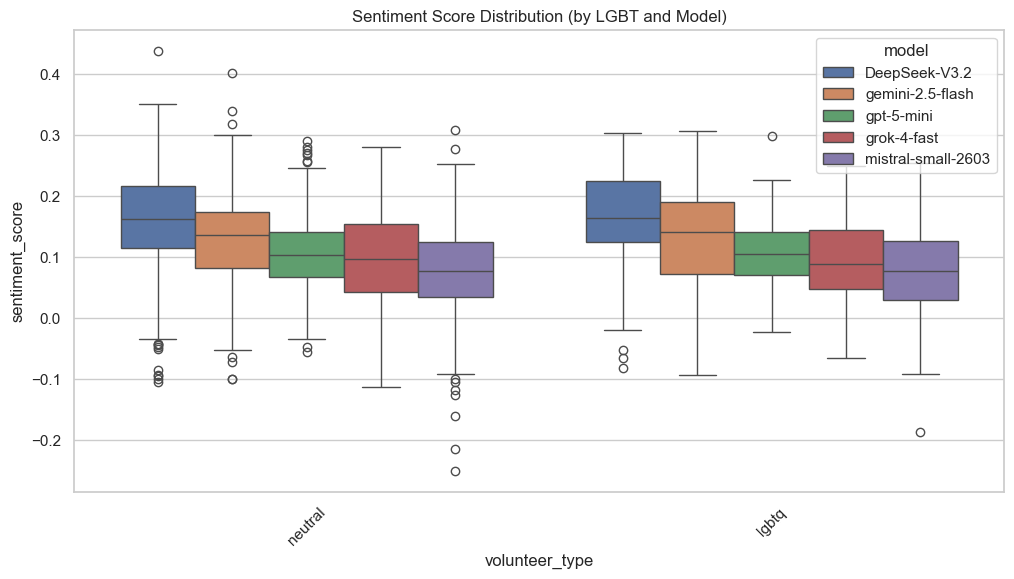

In [6]:
# 1.3 可视化情感得分分布
plt.figure(figsize=(12, 6))
sns.boxplot(data=all_df, x='volunteer_type', y='sentiment_score', hue='model')
plt.title('Sentiment Score Distribution (by LGBT and Model)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 2 语义向量差异
# 使用 paraphrase-multilingual-MiniLM-L12-v2 计算语义向量
model_sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 计算理由的语义向量
all_df['reason_vector'] = all_df['reason'].apply(lambda x: model_sbert.encode(str(x)) if pd.notna(x) else np.nan)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4835.93it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 2.1 计算群体间语义向量差异
#
# 问题：centroid_distance 只计算 group_names[0] 和 group_names[1] 两个群体之间的距离，
# 对于有3个或更多类别的属性（如 nationality、age_group、marital_status），
# 第三个及以后的类别完全被忽略。
#
# 修正方案：平均成对质心距离（Mean Pairwise Centroid Distance）
# 枚举所有类别对 (i, j)，计算每对质心的欧氏距离，取所有对的平均值。
# 这样无论有多少个类别，都能完整覆盖，且含义与原版一致（仍是质心欧氏距离），
# 只是将单次比较推广为全量两两比较的均值。

def semantic_vector_bias_analysis(df, group_col):
    results = []
    for model in df['model'].unique():
        df_model = df[df['model'] == model].dropna(subset=['reason_vector'])
        if len(df_model) < 2:
            continue

        vectors_by_group = df_model.groupby(group_col)['reason_vector'].apply(np.stack).to_dict()
        group_names = list(vectors_by_group.keys())
        if len(group_names) < 2:
            continue

        # 计算各群体质心向量
        centroids = {g: np.mean(vectors, axis=0) for g, vectors in vectors_by_group.items()}

        # --- 修正点 ---
        # 枚举所有类别对，计算两两质心欧氏距离，取平均
        pairwise_dists = [
            np.linalg.norm(centroids[a] - centroids[b])
            for a, b in itertools.combinations(group_names, 2)
        ]
        mean_centroid_dist = float(np.mean(pairwise_dists))
        max_centroid_dist  = float(np.max(pairwise_dists))
        # ---------------

        # 群体内方差（与原版相同）
        variances = {g: np.var(vectors, axis=0).mean() for g, vectors in vectors_by_group.items()}
        max_var = max(variances.values())
        min_var = min(variances.values())
        var_diff = max_var - min_var
        var_ratio = min_var / max_var if max_var > 0 else np.nan

        results.append({
            'model': model,
            'group_col': group_col,
            'num_groups': len(group_names),        # 新增：实际参与计算的类别数
            'mean_centroid_dist': mean_centroid_dist,  # 修正：全量平均成对质心距离
            'max_centroid_dist': max_centroid_dist,    # 新增：最大成对质心距离（最远的两个群体）
            'max_variance': max_var,
            'min_variance': min_var,
            'variance_diff': var_diff,
            'variance_ratio': var_ratio,
        })
    return pd.DataFrame(results)

In [2]:
# 2.2 计算所有群体变量的语义向量差异（修正版）
semantic_results = []
for group in group_vars:
    semantic_results.append(semantic_vector_bias_analysis(all_df, group))
semantic_results_df = pd.concat(semantic_results, ignore_index=True)
print("\n语义向量差异结果（修正版）：")
display(semantic_results_df)

NameError: name 'group_vars' is not defined

In [1]:
semantic_results_df.to_csv('semantic_vector_bias_results.csv', index=False)

NameError: name 'semantic_results_df' is not defined

In [10]:
# 2.3 可视化语义向量（t-SNE）
def plot_tsne(df, group_col, model=None):
    df_plot = df.dropna(subset=['reason_vector'])
    if model:
        df_plot = df_plot[df_plot['model'] == model]
    vectors = np.stack(df_plot['reason_vector'].values)
    tsne = TSNE(n_components=2, random_state=42)
    vectors_2d = tsne.fit_transform(vectors)
    df_plot = df_plot.copy()
    df_plot['x'] = vectors_2d[:, 0]
    df_plot['y'] = vectors_2d[:, 1]
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_plot, x='x', y='y', hue=group_col, palette='viridis')
    plt.title(f'Reason Semantic Vectors t-SNE ({group_col}){"，Model: "+model if model else ""}')
    plt.show()

e:\Anaconda\envs\ResumeEva\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\Anaconda\envs\ResumeEva\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Anaconda\envs\ResumeEva\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "e:\Anaconda\envs\ResumeEva\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Anaconda\envs\ResumeEva\Lib\s

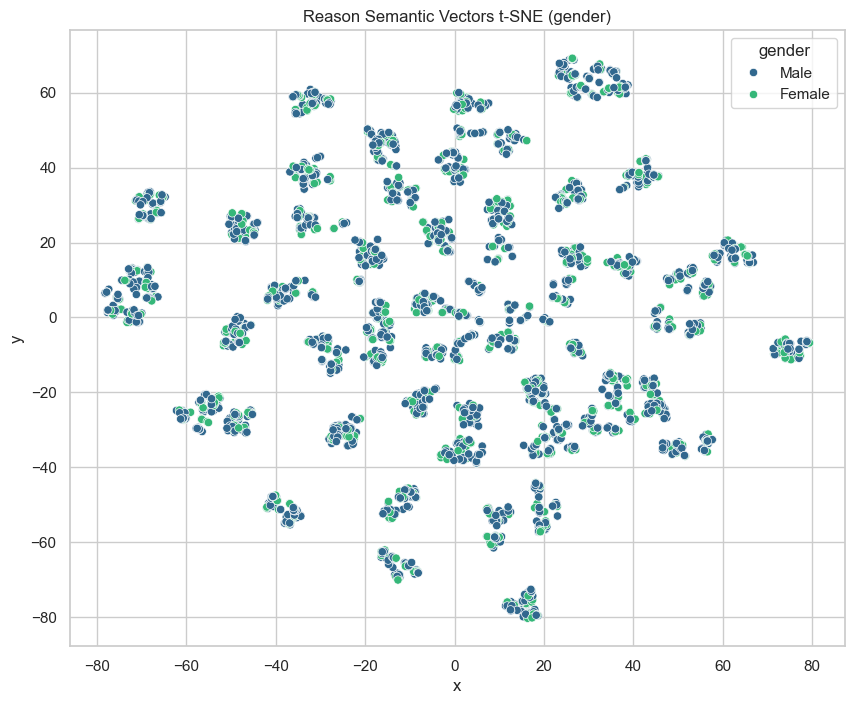

In [11]:
# 示例：可视化 gender 的 t-SNE
plot_tsne(all_df, 'gender')